#  Abusive Language Classifier
### NLP Pipeline for Twitter-like Apps
**Dataset:** `Suspicious_Communication_on_Social_Platforms.csv`  
**Output:** `abusive_classifier.pkl` (ready for production inference)

---
**Pipeline:**
- TF-IDF (word + char n-grams) → Logistic Regression
- ~89% accuracy | 0.95 ROC-AUC on this dataset


In [ ]:
# ─── Step 1: Install & Import Dependencies ───────────────────────────────────
!pip install scikit-learn pandas numpy matplotlib seaborn joblib -q

import re, pickle, warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model         import LogisticRegression
from sklearn.pipeline             import Pipeline, FeatureUnion
from sklearn.model_selection      import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics              import (classification_report, confusion_matrix,
                                          roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.preprocessing        import LabelEncoder
from sklearn.exceptions           import UndefinedMetricWarning
import joblib

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
print("✅ All dependencies loaded!")


✅ All dependencies loaded!


---
##  Step 2: Upload your CSV file
Run the cell below — a **file picker** will appear.  
Upload `Suspicious_Communication_on_Social_Platforms.csv`.


In [ ]:
from google.colab import files

print("👇 Click 'Choose Files' and upload your CSV ...")
uploaded = files.upload()

CSV_FILENAME = list(uploaded.keys())[0]
print(f"\n✅ Uploaded: {CSV_FILENAME}")


👇 Click 'Choose Files' and upload your CSV ...


Saving Suspicious Communication on Social Platforms.csv to Suspicious Communication on Social Platforms.csv

✅ Uploaded: Suspicious Communication on Social Platforms.csv


---
##  Step 3: Exploratory Data Analysis

In [ ]:
# ─── Load & inspect ───────────────────────────────────────────────────────────
df = pd.read_csv(CSV_FILENAME)
df.columns = df.columns.str.strip()
df = df.dropna(subset=["comments", "tagging"])
df["label"] = df["tagging"].astype(int)

print(f"Total samples : {len(df):,}")
print(f"Abusive  (1)  : {df['label'].sum():,}  ({df['label'].mean()*100:.1f}%)")
print(f"Clean    (0)  : {(df['label']==0).sum():,}  ({(1-df['label'].mean())*100:.1f}%)")
print("\nSample rows:")
df[["comments","label"]].sample(5, random_state=42)


Total samples : 20,001
Abusive  (1)  : 7,822  (39.1%)
Clean    (0)  : 12,179  (60.9%)

Sample rows:


,comments,label
10650,fucking beautiful shoes.,0
2041,fuck you change your name. Do you know who I ...,1
8668,Per my other tweets I've (hopefully temporari...,0
1114,"""If you not on twitter you're a fucking moron""...",1
13902,"Yep he left with supposed ""mercury poisoning""...",0


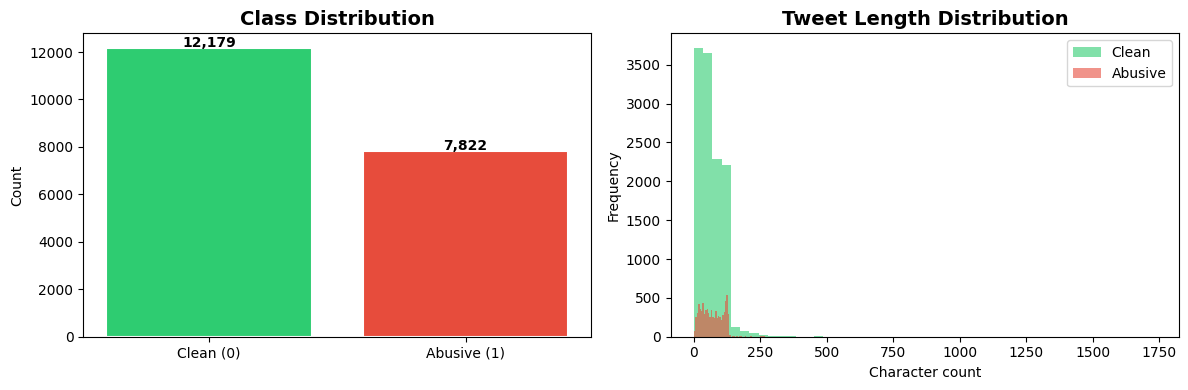

✅ EDA complete!


In [ ]:
# ─── Class distribution plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df["label"].value_counts().sort_index()
axes[0].bar(["Clean (0)", "Abusive (1)"], counts.values,
            color=["#2ecc71", "#e74c3c"], edgecolor="white", linewidth=1.5)
axes[0].set_title("Class Distribution", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontweight="bold")

# Text length distribution
df["text_len"] = df["comments"].str.len()
for lbl, color, name in [(0, "#2ecc71", "Clean"), (1, "#e74c3c", "Abusive")]:
    axes[1].hist(df[df["label"]==lbl]["text_len"], bins=50,
                 alpha=0.6, color=color, label=name)
axes[1].set_title("Tweet Length Distribution", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Character count")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ EDA complete!")


---
## Step 4: Text Pre-processing

In [ ]:
# ─── Twitter-aware text cleaner ───────────────────────────────────────────────
_URL_RE     = re.compile(r"https?://\S+|www\.\S+")
_MENTION_RE = re.compile(r"@\w+")
_HASHTAG_RE = re.compile(r"#(\w+)")
_REPEAT_RE  = re.compile(r"(.)\1{2,}")
_SPACE_RE   = re.compile(r"\s+")

def clean_text(text: str) -> str:
    """Lightweight Twitter-aware cleaner."""
    text = str(text).lower()
    text = _URL_RE.sub(" url ", text)           # URLs → token
    text = _MENTION_RE.sub(" user ", text)       # mention → token
    text = _HASHTAG_RE.sub(r" \1 ", text)      # #tag → tag word
    text = _REPEAT_RE.sub(r"\1\1", text)      # looool → lool (normalise)
    # Keep punctuation — profanity often relies on it (f***, f_ck …)
    text = _SPACE_RE.sub(" ", text).strip()
    return text

df["text_clean"] = df["comments"].apply(clean_text)

# Show before / after
print("Before:", df["comments"].iloc[0])
print("After :", df["text_clean"].iloc[0])
print(f"\n✅ Cleaned {len(df):,} tweets!")


Before:  Get fucking real dude.
After : get fucking real dude.

✅ Cleaned 20,001 tweets!


---
## Step 5: Feature Engineering + Model Pipeline

**Two TF-IDF views combined via `FeatureUnion`:**
| View | Analyzer | n-gram range | Why |
|------|----------|-------------|-----|
| Word | `word` | (1, 3) | Semantic context |
| Char | `char_wb` | (3, 5) | Catches obfuscated profanity (`f**k`, `f_ck`) |

**Classifier:** Logistic Regression with `class_weight='balanced'` to handle the 60/40 imbalance.


In [ ]:
# ─── TF-IDF Feature Union ─────────────────────────────────────────────────────
word_tfidf = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 3),
    max_features=50_000,
    sublinear_tf=True,
    min_df=2,
    strip_accents="unicode",
)

char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    max_features=50_000,
    sublinear_tf=True,
    min_df=3,
)

features = FeatureUnion(
    transformer_list=[
        ("word", word_tfidf),
        ("char", char_tfidf),
    ]
)

# ─── Full sklearn Pipeline ────────────────────────────────────────────────────
pipeline = Pipeline([
    ("tfidf", features),
    ("clf",   LogisticRegression(
                  C=1.0,
                  solver="lbfgs",
                  max_iter=1000,
                  class_weight="balanced",  # handles 60/40 imbalance
                  random_state=42,
              )),
])

print("✅ Pipeline defined!")
print(pipeline)


✅ Pipeline defined!
Pipeline(steps=[('tfidf',
                 FeatureUnion(transformer_list=[('word',
                                                 TfidfVectorizer(max_features=50000,
                                                                 min_df=2,
                                                                 ngram_range=(1,
                                                                              3),
                                                                 strip_accents='unicode',
                                                                 sublinear_tf=True)),
                                                ('char',
                                                 TfidfVectorizer(analyzer='char_wb',
                                                                 max_features=50000,
                                                                 min_df=3,
                                                                 ngram_range=(3,
               

---
##  Step 6: Train / Test Split

In [ ]:
X = df["text_clean"].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y,           # preserve class balance in both splits
)

print(f"Train : {len(X_train):,} samples")
print(f"Test  : {len(X_test):,}  samples")
print(f"Train abusive% : {y_train.mean()*100:.1f}%")
print(f"Test  abusive% : {y_test.mean()*100:.1f}%")


Train : 16,000 samples
Test  : 4,001  samples
Train abusive% : 39.1%
Test  abusive% : 39.1%


---
## Step 7: 5-Fold Cross-Validation

Running 5-fold cross-validation ... (may take ~30s)

Fold F1 scores : [0.8082 0.8029 0.801  0.8185 0.8014]
Mean ± Std     : 0.8064 ± 0.0066


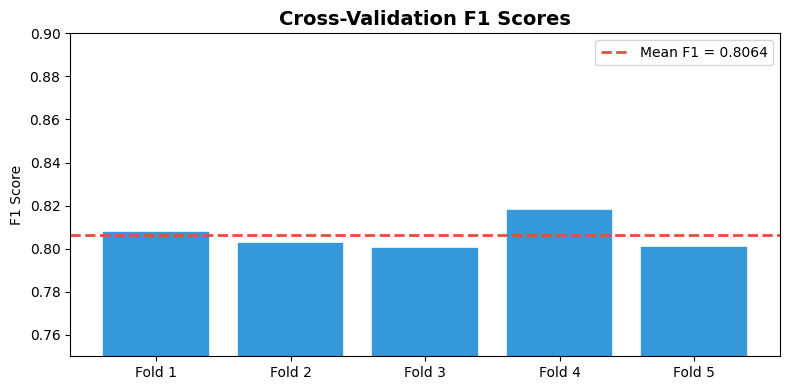

In [ ]:
print("Running 5-fold cross-validation ... (may take ~30s)")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X_train, y_train,
                             cv=cv, scoring="f1", n_jobs=-1)

print(f"\nFold F1 scores : {cv_scores.round(4)}")
print(f"Mean ± Std     : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Plot CV scores
plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_scores, color="#3498db", edgecolor="white", linewidth=1.2)
plt.axhline(cv_scores.mean(), color="#e74c3c", linestyle="--",
            linewidth=2, label=f"Mean F1 = {cv_scores.mean():.4f}")
plt.xticks(range(1, 6), [f"Fold {i}" for i in range(1, 6)])
plt.ylabel("F1 Score")
plt.title("Cross-Validation F1 Scores", fontsize=14, fontweight="bold")
plt.ylim(0.75, 0.90)
plt.legend()
plt.tight_layout()
plt.savefig("cv_scores.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Step 8: Train Final Model on Full Training Set

In [ ]:
print("Fitting final model ...")
pipeline.fit(X_train, y_train)
print("✅ Training complete!")


Fitting final model ...
✅ Training complete!


---
## Step 9: Evaluate on Held-out Test Set

In [ ]:
y_pred  = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("=" * 55)
print("Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred,
      target_names=["clean (0)", "abusive (1)"], digits=4))
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}")


Classification Report
              precision    recall  f1-score   support

   clean (0)     0.9112    0.9060    0.9086      2436
 abusive (1)     0.8550    0.8626    0.8588      1565

    accuracy                         0.8890      4001
   macro avg     0.8831    0.8843    0.8837      4001
weighted avg     0.8892    0.8890    0.8891      4001

ROC-AUC : 0.9502


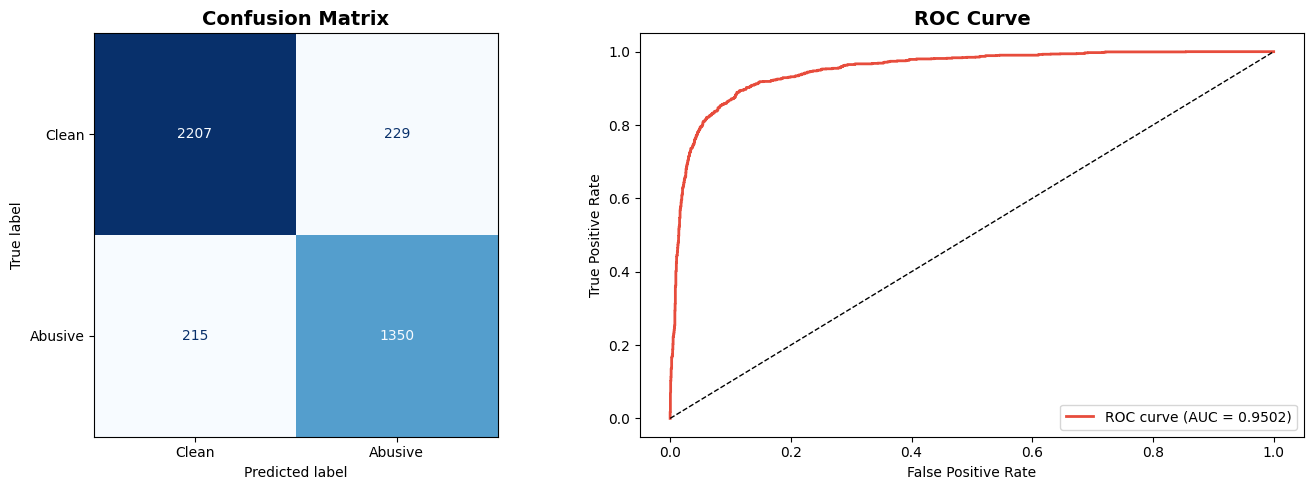

In [ ]:
# ─── Confusion matrix ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Clean", "Abusive"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix", fontsize=14, fontweight="bold")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score   = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color="#e74c3c", lw=2,
             label=f"ROC curve (AUC = {auc_score:.4f})")
axes[1].plot([0,1],[0,1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontsize=14, fontweight="bold")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig("eval_plots.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Step 10: Inspect Top Discriminating Features

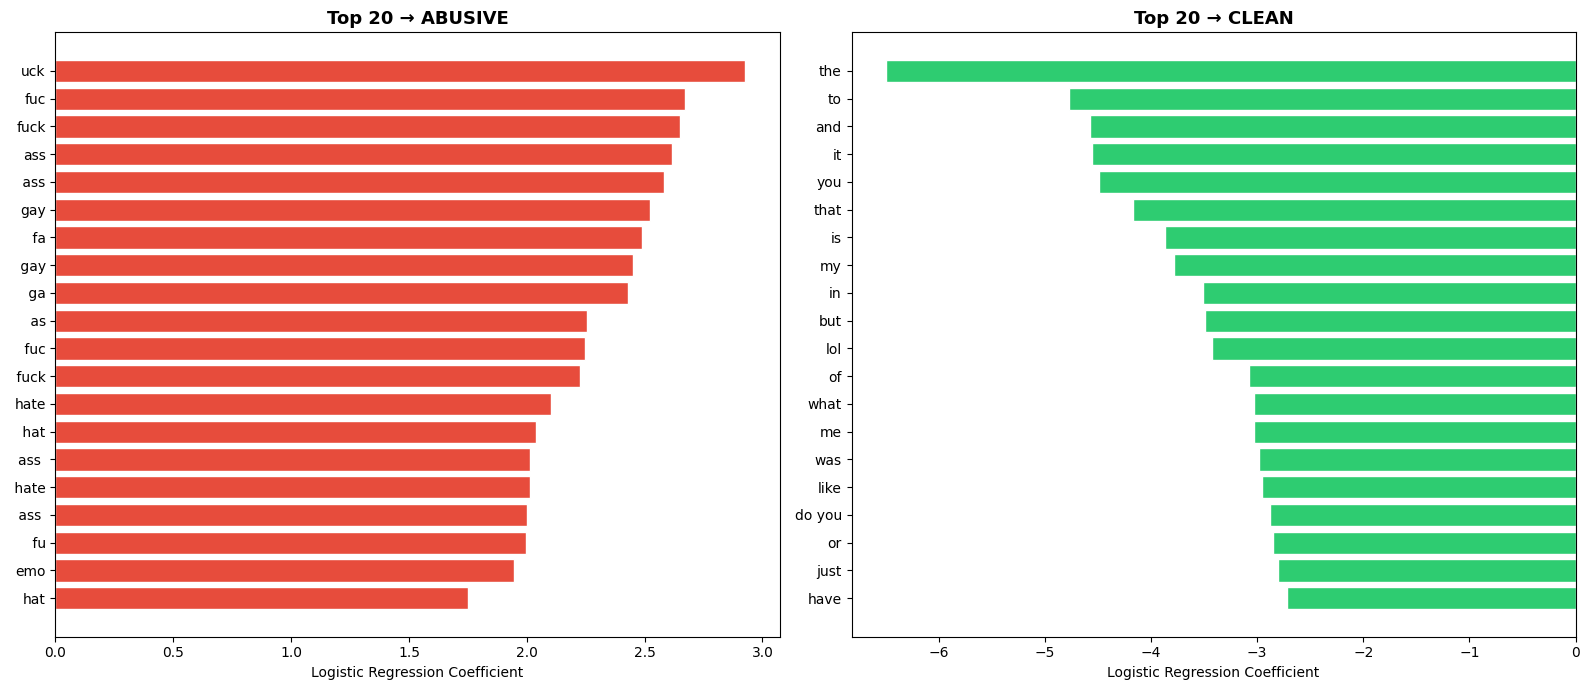

In [ ]:
# ─── Top tokens learned by the model ─────────────────────────────────────────
feature_names = np.array(pipeline.named_steps["tfidf"].get_feature_names_out())
coef          = pipeline.named_steps["clf"].coef_[0]

N = 20
top_abusive_idx = np.argsort(coef)[-N:][::-1]
top_clean_idx   = np.argsort(coef)[:N]

top_abusive = [(feature_names[i], coef[i]) for i in top_abusive_idx]
top_clean   = [(feature_names[i], coef[i]) for i in top_clean_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, data, color, title in [
    (axes[0], top_abusive, "#e74c3c", f"Top {N} → ABUSIVE"),
    (axes[1], top_clean,   "#2ecc71", f"Top {N} → CLEAN"),
]:
    labels = [d[0].replace("word__","").replace("char__","") for d in data]
    scores = [d[1] for d in data]
    ax.barh(labels[::-1], scores[::-1], color=color, edgecolor="white")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Logistic Regression Coefficient")

plt.tight_layout()
plt.savefig("top_features.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Step 11: Export Model as `.pkl`
Two artefacts are saved and downloaded:
- `abusive_classifier.pkl` — full sklearn Pipeline (vectoriser + classifier)
- `label_encoder.pkl` — LabelEncoder (for inverse_transform if needed)


In [ ]:
# ─── Save with pickle ─────────────────────────────────────────────────────────
PKL_MODEL   = "abusive_classifier.pkl"

with open(PKL_MODEL, "wb") as f:
    pickle.dump(pipeline, f, protocol=pickle.HIGHEST_PROTOCOL)



print(f"✅ Saved  {PKL_MODEL}  ({os.path.getsize(PKL_MODEL)/1e6:.2f} MB)")


✅ Saved  abusive_classifier.pkl  (4.43 MB)


In [ ]:
# ─── Download to your machine ─────────────────────────────────────────────────
from google.colab import files

files.download(PKL_MODEL)
print("📥 Downloads triggered!")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Downloads triggered!


---
## Step 12: Inference  — Use the Saved Model
This is the code you drop into your Twitter-like app backend.


In [ ]:
# ─── Load from .pkl ───────────────────────────────────────────────────────────
with open(PKL_MODEL, "rb") as f:
    loaded_pipeline = pickle.load(f)

print("✅ Model loaded from .pkl")


✅ Model loaded from .pkl


In [ ]:
# ─── Single-tweet prediction ──────────────────────────────────────────────────
def predict_tweet(text: str, threshold: float = 0.50) -> dict:
    """
    Classify a single tweet.
    Returns label, abusive probability score, and binary tag.
    """
    cleaned = clean_text(text)
    proba   = loaded_pipeline.predict_proba([cleaned])[0]
    score   = float(proba[1])           # P(abusive)
    tag     = int(score >= threshold)
    label   = "🔴 ABUSIVE" if tag else "🟢 CLEAN"
    return {"label": label, "score": round(score, 4), "tag": tag}


# ─── Batch prediction (efficient — one vectorisation pass) ────────────────────
def predict_batch(texts: list, threshold: float = 0.50) -> pd.DataFrame:
    cleaned = [clean_text(t) for t in texts]
    probas  = loaded_pipeline.predict_proba(cleaned)[:, 1]
    results = []
    for text, score in zip(texts, probas):
        score = float(score)
        tag   = int(score >= threshold)
        results.append({
            "tweet": text,
            "label": "ABUSIVE" if tag else "CLEAN",
            "score": round(score, 4),
            "tag"  : tag,
        })
    return pd.DataFrame(results)


# ─── Demo ─────────────────────────────────────────────────────────────────────
test_tweets = [
    "Good morning everyone, hope you have a wonderful day!",
    "I absolutely hate you, go f*** yourself",
    "Just watched the game, what an amazing match!",
    "You are such a stupid idiot, get out of here",
    "Looking forward to the weekend with family 😊",
]

print("─" * 60)
for tw in test_tweets:
    r = predict_tweet(tw)
    print(f"{r['label']}  score={r['score']:.3f}  |  {tw[:60]}")
print("─" * 60)


────────────────────────────────────────────────────────────
🟢 CLEAN  score=0.058  |  Good morning everyone, hope you have a wonderful day!
🔴 ABUSIVE  score=0.516  |  I absolutely hate you, go f*** yourself
🟢 CLEAN  score=0.440  |  Just watched the game, what an amazing match!
🔴 ABUSIVE  score=0.606  |  You are such a stupid idiot, get out of here
🟢 CLEAN  score=0.474  |  Looking forward to the weekend with family 😊
────────────────────────────────────────────────────────────


In [ ]:
# ─── Batch demo as DataFrame ──────────────────────────────────────────────────
batch_df = predict_batch(test_tweets)
batch_df.style.applymap(
    lambda v: "background-color:#ffe0e0" if v == "ABUSIVE"
              else ("background-color:#e0ffe0" if v == "CLEAN" else ""),
    subset=["label"]
)


/tmp/ipykernel_630/2651573661.py:3: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  batch_df.style.applymap(


,tweet,label,score,tag
0,"Good morning everyone, hope you have a wonderful day!",CLEAN,0.057500,0
1,"I absolutely hate you, go f*** yourself",ABUSIVE,0.516100,1
2,"Just watched the game, what an amazing match!",CLEAN,0.439500,0
3,"You are such a stupid idiot, get out of here",ABUSIVE,0.606200,1
4,Looking forward to the weekend with family 😊,CLEAN,0.473800,0


---
## 🎚️ Bonus: Threshold Tuning
The default threshold is **0.5**. For a content moderation system you may want:
- **Lower threshold (e.g. 0.35)** → catch more abusive content (higher recall, more false positives)
- **Higher threshold (e.g. 0.65)** → only flag high-confidence cases (higher precision, fewer flags)


 threshold  precision  recall     f1
      0.30     0.6680  0.9668 0.7901
      0.35     0.7203  0.9476 0.8184
      0.40     0.7694  0.9252 0.8402
      0.45     0.8142  0.9042 0.8568
      0.50     0.8550  0.8626 0.8588
      0.55     0.8869  0.8268 0.8558
      0.60     0.9172  0.7783 0.8420
      0.65     0.9392  0.7010 0.8028
      0.70     0.9538  0.5936 0.7318


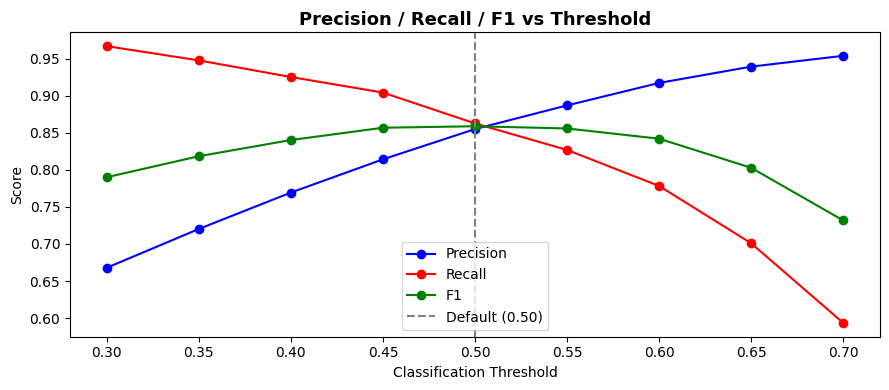

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

thresholds = np.arange(0.30, 0.75, 0.05)
rows = []
for t in thresholds:
    preds = (y_proba >= t).astype(int)
    p, r, f, _ = precision_recall_fscore_support(y_test, preds,
                                                  average="binary", zero_division=0)
    rows.append({"threshold": round(t,2), "precision": round(p,4),
                 "recall": round(r,4), "f1": round(f,4)})

thresh_df = pd.DataFrame(rows)
print(thresh_df.to_string(index=False))

plt.figure(figsize=(9, 4))
plt.plot(thresh_df["threshold"], thresh_df["precision"], "b-o", label="Precision")
plt.plot(thresh_df["threshold"], thresh_df["recall"],    "r-o", label="Recall")
plt.plot(thresh_df["threshold"], thresh_df["f1"],        "g-o", label="F1")
plt.axvline(0.50, linestyle="--", color="gray", label="Default (0.50)")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Threshold", fontsize=13, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("threshold_tuning.png", dpi=150, bbox_inches="tight")
plt.show()
